# 06 — Feature: Memory
Parses the `Memory` string (e.g., `256GB SSD + 1TB HDD`) into structured numeric features.

**Output features:** `Mem_SSD_GB`, `Mem_HDD_GB`, `Mem_Flash_GB`, `Mem_eMMC_GB`, `Mem_Total_GB`, `Mem_HasSSD`, `Mem_IsCombo`, `Mem_IsSingleStorage`, `Mem_IsHybridStorage`, `Mem_PrimaryType_TE`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
ld = pd.read_csv("laptop_data_features.csv")
print(f"Shape: {ld.shape}")

Shape: (1303, 26)


In [3]:
# Explore Memory
print(ld['Memory'].value_counts().head(20))
print(f"\nUnique Memory configs: {ld['Memory'].nunique()}")

Memory
256GB SSD               412
1TB HDD                 223
500GB HDD               132
512GB SSD               118
128GB SSD +  1TB HDD     94
128GB SSD                76
256GB SSD +  1TB HDD     73
32GB Flash Storage       38
2TB HDD                  16
64GB Flash Storage       15
512GB SSD +  1TB HDD     14
1TB SSD                  14
256GB SSD +  2TB HDD     10
1.0TB Hybrid              9
256GB Flash Storage       8
16GB Flash Storage        7
32GB SSD                  6
180GB SSD                 5
128GB Flash Storage       4
16GB SSD                  3
Name: count, dtype: int64

Unique Memory configs: 39


In [4]:
def parse_size_gb(size_str):
    """Convert '500GB' or '1TB' to integer GB."""
    size_str = size_str.strip()
    match = re.match(r'(\d+\.?\d*)\s*(GB|TB)', size_str, re.IGNORECASE)
    if not match:
        return 0
    val, unit = float(match.group(1)), match.group(2).upper()
    return int(val * 1024) if unit == 'TB' else int(val)

def parse_memory(mem_str):
    """
    Parses memory string into storage breakdown by type.
    Handles single and combo drives (e.g., '256GB SSD +  1TB HDD').
    """
    if pd.isna(mem_str):
        return pd.Series([0, 0, 0, 0, 'Unknown'],
                         index=['Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_PrimaryType'])
    ssd_gb = hdd_gb = flash_gb = emmc_gb = 0
    for part in mem_str.split('+'):
        part = part.strip()
        size_match = re.match(r'(\d+\.?\d*\s*(?:GB|TB))', part, re.IGNORECASE)
        size = parse_size_gb(size_match.group(1)) if size_match else 0
        pl = part.lower()
        if 'ssd' in pl:
            ssd_gb += size
        elif 'hdd' in pl or 'hard disk' in pl:
            hdd_gb += size
        elif 'flash' in pl:
            flash_gb += size
        elif 'emmc' in pl:
            emmc_gb += size
        else:
            ssd_gb += size   # fallback (e.g., bare "128GB")
    type_scores = {'SSD': ssd_gb, 'HDD': hdd_gb, 'Flash': flash_gb, 'eMMC': emmc_gb}
    primary = max(type_scores, key=type_scores.get) if any(type_scores.values()) else 'Unknown'
    return pd.Series([ssd_gb, hdd_gb, flash_gb, emmc_gb, primary],
                     index=['Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_PrimaryType'])

ld[['Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_PrimaryType']] = ld['Memory'].apply(parse_memory)
ld['Mem_Total_GB'] = ld['Mem_SSD_GB'] + ld['Mem_HDD_GB'] + ld['Mem_Flash_GB'] + ld['Mem_eMMC_GB']
ld['Mem_HasSSD']   = (ld['Mem_SSD_GB'] > 0).astype(int)
ld['Mem_IsCombo']  = ((ld['Mem_SSD_GB'] > 0) & (ld['Mem_HDD_GB'] > 0)).astype(int)

# Count how many distinct storage types are present
ld['_storage_type_count'] = (
    (ld['Mem_SSD_GB']   > 0).astype(int) +
    (ld['Mem_HDD_GB']   > 0).astype(int) +
    (ld['Mem_Flash_GB'] > 0).astype(int) +
    (ld['Mem_eMMC_GB']  > 0).astype(int)
)
ld['Mem_IsSingleStorage'] = (ld['_storage_type_count'] == 1).astype(int)
ld['Mem_IsHybridStorage'] = (ld['_storage_type_count'] >= 2).astype(int)
ld.drop(columns=['_storage_type_count'], inplace=True)

print("Parse sample:")
print(ld[['Memory', 'Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Total_GB', 'Mem_PrimaryType',
          'Mem_IsSingleStorage', 'Mem_IsHybridStorage']].head(10).to_string())

Parse sample:
                Memory  Mem_SSD_GB  Mem_HDD_GB  Mem_Total_GB Mem_PrimaryType  Mem_IsSingleStorage  Mem_IsHybridStorage
0            128GB SSD         128           0           128             SSD                    1                    0
1  128GB Flash Storage           0           0           128           Flash                    1                    0
2            256GB SSD         256           0           256             SSD                    1                    0
3            512GB SSD         512           0           512             SSD                    1                    0
4            256GB SSD         256           0           256             SSD                    1                    0
5            500GB HDD           0         500           500             HDD                    1                    0
6  256GB Flash Storage           0           0           256           Flash                    1                    0
7  256GB Flash Storage           0

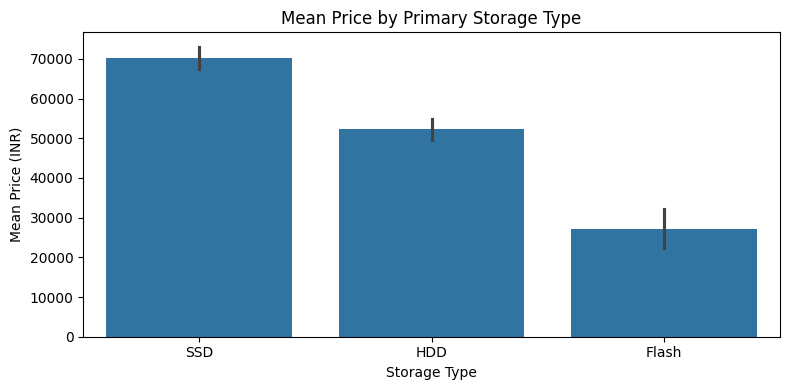

In [5]:
# Visualize primary type vs Price
plt.figure(figsize=(8, 4))
sns.barplot(data=ld, x='Mem_PrimaryType', y='Price', estimator='mean',
            order=ld.groupby('Mem_PrimaryType')['Price'].mean().sort_values(ascending=False).index)
plt.title("Mean Price by Primary Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Mean Price (INR)")
plt.tight_layout()
plt.show()

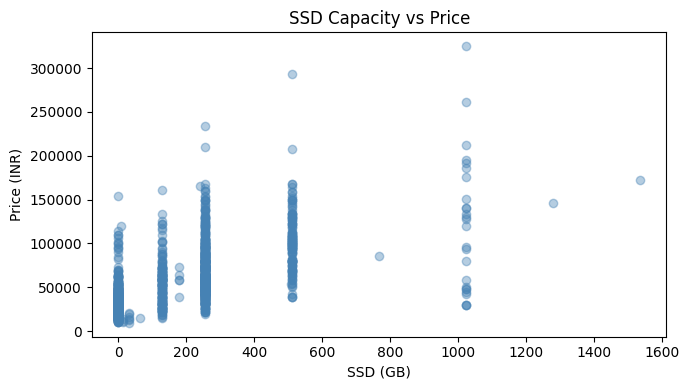

In [6]:
# SSD size vs Price
plt.figure(figsize=(7, 4))
plt.scatter(ld['Mem_SSD_GB'], ld['Price'], alpha=0.4, color='steelblue')
plt.title("SSD Capacity vs Price")
plt.xlabel("SSD (GB)")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

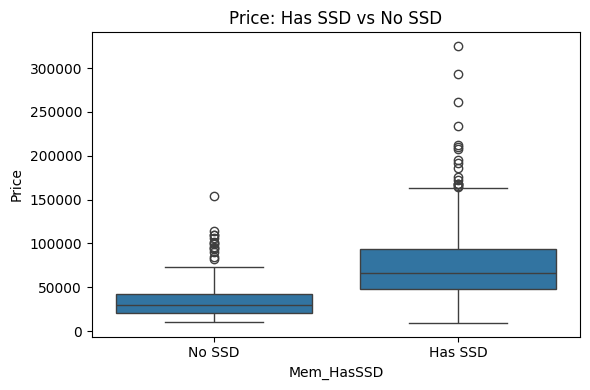

In [7]:
# HasSSD vs Price (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=ld, x='Mem_HasSSD', y='Price')
plt.title("Price: Has SSD vs No SSD")
plt.xticks([0, 1], ['No SSD', 'Has SSD'])
plt.tight_layout()
plt.show()

In [8]:
# Target encode primary type
pt_mean = ld.groupby('Mem_PrimaryType')['Price'].mean()
ld['Mem_PrimaryType_TE'] = ld['Mem_PrimaryType'].map(pt_mean)

In [9]:
# Correlation with Price
mem_cols = ['Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Total_GB', 'Mem_HasSSD', 'Mem_IsCombo',
            'Mem_IsSingleStorage', 'Mem_IsHybridStorage', 'Mem_PrimaryType_TE']
print("Correlation with Price:")
print(ld[mem_cols + ['Price']].corr()['Price'].sort_values(ascending=False))

Correlation with Price:
Price                  1.000000
Mem_SSD_GB             0.617622
Mem_HasSSD             0.509002
Mem_PrimaryType_TE     0.318444
Mem_IsHybridStorage    0.300507
Mem_IsCombo            0.298471
Mem_Total_GB           0.157830
Mem_HDD_GB            -0.094856
Mem_IsSingleStorage   -0.300507
Name: Price, dtype: float64


In [10]:
# Drop raw and intermediate columns
ld.drop(columns=['Memory', 'Mem_PrimaryType'], inplace=True)

In [11]:
ld.to_csv("laptop_data_features.csv", index=False)
print("Saved: laptop_data_features.csv")
print(f"Shape: {ld.shape}")
print(f"Columns: {list(ld.columns)}")

Saved: laptop_data_features.csv
Shape: (1303, 35)
Columns: ['Inches', 'Ram', 'Gpu', 'OpSys', 'Weight', 'Price', 'Company_TE', 'Type_2 in 1 Convertible', 'Type_Gaming', 'Type_Netbook', 'Type_Notebook', 'Type_Ultrabook', 'Type_Workstation', 'Screen_Width', 'Screen_Height', 'Screen_PPI', 'Screen_IsTouchscreen', 'Screen_IsIPS', 'Screen_IsRetina', 'Screen_IsFullHD', 'Screen_Is4K', 'CPU_GHz', 'CPU_Brand_TE', 'CPU_Family_TE', 'CPU_TE', 'Mem_SSD_GB', 'Mem_HDD_GB', 'Mem_Flash_GB', 'Mem_eMMC_GB', 'Mem_Total_GB', 'Mem_HasSSD', 'Mem_IsCombo', 'Mem_IsSingleStorage', 'Mem_IsHybridStorage', 'Mem_PrimaryType_TE']
